In [12]:
from Bio import SeqIO
import pandas as pd
import csv

from sklearn.model_selection import train_test_split

def avg(l):
    t = 0
    for i in l:
        t += i
    return t/len(l)

with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[]}

#with open('csv/condensation_starter_train_3OH_removepsed.csv') as binned_data:
df = pd.read_csv('csv/condensation_starter.csv')
# df = pd.DataFrame(binned_data_seqs)
df['aligned_seq'] = df['cond_accession'].apply(lambda x: aligned_seqs_dict.get(x))
df = df.dropna(subset=['3OH'])
df = df.drop(columns=['accession','category','size_carbons','size_cno','3_heteroatom','type','aa_seq','tax_cat'])

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties:
    reader = csv.DictReader(aa_properties, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = float(row[aa_property])
                if not aa_property in properties_list:
                    properties_list.append(aa_property)

features = {
    'WOLS870101': [700,842,491],
    'WOLS870102': [829],
    'WOLS870103': [123],
    'FAUJ880109': [],
    'GRAR740102': [],
    'RADA880108': [],
    'ZIMJ680103': [],
    'TSAJ990101': [614],
    'CHOP780201': [728,548],
    'CHOP780202': [642],
    'CHOP780203': [773],
    'ZIMJ680104': [],
    'NEU1': [],
    'NEU2': [121,415,462,508],
    'NEU3': [555]
}

# top 5 from mAR-FA, top 5 from mFA-AR, top 2 |mFA-AR|/|mFA-FA| (555 & 134), and 123,
features = {
    'WOLS870101': [750,773,161,555],
    'WOLS870102': [],
    'WOLS870103': [548,123,555],
    'FAUJ880109': [134],
    'GRAR740102': [710],
    'RADA880108': [],
    'ZIMJ680103': [150],
    'TSAJ990101': [],
    'CHOP780201': [769],
    'CHOP780202': [],
    'CHOP780203': [],
    'ZIMJ680104': [134,821],
    'NEU1': [],
    'NEU2': [],
    'NEU3': [227]
}
783,822,824,826
features = {
    'WOLS870101': [121,123,730,732,766,768,769,783,822,824,826],
    'WOLS870102': [121,123,730,732,766,768,769,783,822,824,826],
    'WOLS870103': [121,123,730,732,766,768,769,783,822,824,826],
    'FAUJ880109': [121,123,730,732,766,768,769,783,822,824,826],
    'GRAR740102': [121,123,730,732,766,768,769,783,822,824,826],
    'RADA880108': [121,123,730,732,766,768,769,783,822,824,826],
    'ZIMJ680103': [121,123,730,732,766,768,769,783,822,824,826],
    'TSAJ990101': [121,123,730,732,766,768,769,783,822,824,826],
    'CHOP780201': [121,123,730,732,766,768,769,783,822,824,826],
    'CHOP780202': [121,123,730,732,766,768,769,783,822,824,826],
    'CHOP780203': [121,123,730,732,766,768,769,783,822,824,826],
    'ZIMJ680104': [121,123,730,732,766,768,769,783,822,824,826],
    'NEU1': [121,123,730,732,766,768,769,783,822,824,826],
    'NEU2': [121,123,730,732,766,768,769,783,822,824,826],
    'NEU3': [121,123,730,732,766,768,769,783,822,824,826]
}
features = {
    'WOLS870101': [],
    'WOLS870102': [],
    'WOLS870103': [],
    'FAUJ880109': [],
    'GRAR740102': [],
    'RADA880108': [],
    'ZIMJ680103': [],
    'TSAJ990101': [],
    'CHOP780201': [],
    'CHOP780202': [],
    'CHOP780203': [],
    'ZIMJ680104': [121,122,123,730,732,766,767,768,769,783,822,824,826],
    'NEU1': [],
    'NEU2': [],
    'NEU3': [] 
}

features = {
    'WOLS870101': [766,768,783, 822],
    'WOLS870102': [],
    'WOLS870103': [],
    'FAUJ880109': [826],
    'GRAR740102': [],
    'RADA880108': [],
    'ZIMJ680103': [],
    'TSAJ990101': [730],
    'CHOP780201': [],
    'CHOP780202': [],
    'CHOP780203': [769, 732],
    'ZIMJ680104': [],
    'NEU1': [769],
    'NEU2': [123],
    'NEU3': [] 
}
#print(df)
c = 0
ml_df_full = df.copy()
for aa_property in features:
    if features[aa_property] != []:
        for pos in features[aa_property]:
            ml_df_full[aa_property + '_' + str(pos)] = df['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][aa_property])
            ml_df_full = ml_df_full.copy()
            c += 1

ml_df_train, ml_df_test = train_test_split(ml_df_full, test_size=0.2, stratify=df['3OH'],random_state=1)

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_70926/3665942308.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue="3OH", fill=True, alpha=0.5)


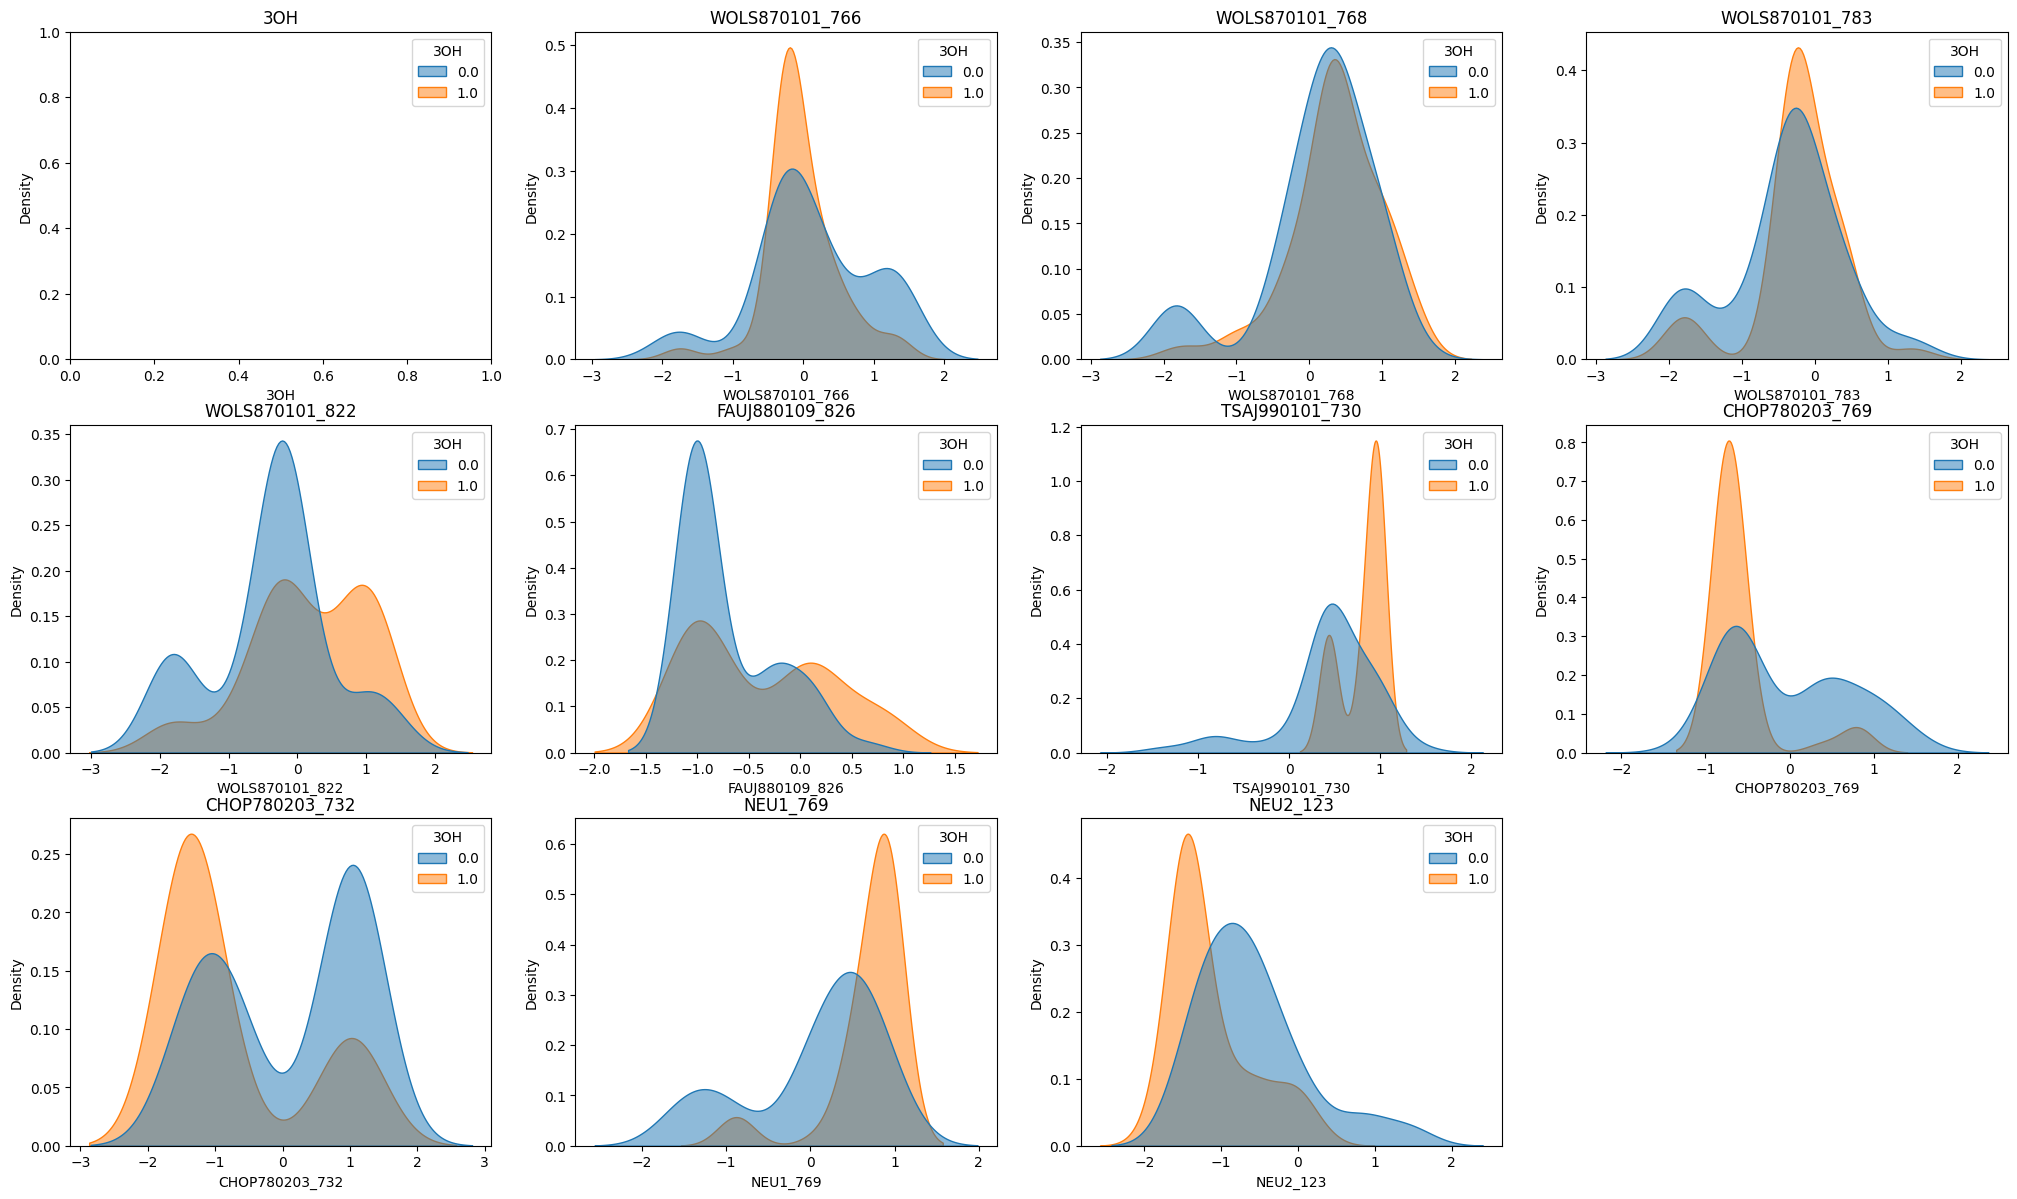

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = ml_df_train.drop(['cond_accession', 'aligned_seq'], axis=1)


numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set up a reasonably sized figure
plt.figure(figsize=(25, 40))

# Plot KDE for each numeric feature, colored by category
for i, column in enumerate(numeric_columns[:32]):  # Limit to first 10 features for example
    plt.subplot(8, 4, i+1)  # Adjust grid size based on how many features you want to display
    sns.kdeplot(data=df, x=column, hue="3OH", fill=True, alpha=0.5)
    plt.title(column)
    # plt.tight_layout()

plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
import pickle

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.025,max_depth=4,min_samples_leaf=2,max_leaf_nodes=2,n_estimators=100,min_samples_split=2, max_features="log2", random_state=1)
y = ml_df_full['3OH']
X = ml_df_full.drop(['cond_accession','3OH', 'aligned_seq'], axis=1)

rf_model_cv.fit(X,y)

with open('rf_3OH.pkl', 'wb') as f:
    pickle.dump(rf_model_cv, f)



## random forest

[0.85       0.68421053 0.78947368 0.84210526 0.84210526] avg: 0.801578947368421
19     1.0
115    0.0
116    0.0
110    1.0
193    0.0
      ... 
120    1.0
178    1.0
34     1.0
169    0.0
104    0.0
Name: 3OH, Length: 96, dtype: float64 [1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.
 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0.]
Confusion Matrix:
 [[42 10]
 [ 9 35]]


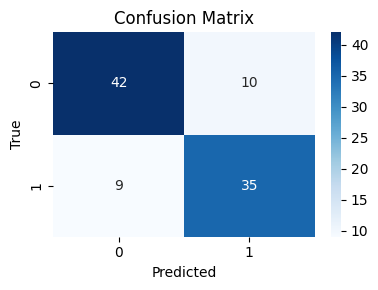


training accuracy :  [0.82894737 0.84415584 0.81818182 0.80519481 0.81818182] avg: 0.8229323308270677
test accuracy :  [0.85       0.68421053 0.78947368 0.84210526 0.84210526] avg: 0.801578947368421
NEU1_769          0.196536
CHOP780203_769    0.162062
NEU2_123          0.149287
CHOP780203_732    0.124771
TSAJ990101_730    0.092408
WOLS870101_768    0.065111
WOLS870101_783    0.058565
WOLS870101_766    0.053115
WOLS870101_822    0.050216
FAUJ880109_826    0.047929
dtype: float64


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle


y_cv = ml_df_train['3OH']
X_cv = ml_df_train.drop(['cond_accession', '3OH', 'aligned_seq'], axis=1)


i=1
#X, y = shuffle(X, y, random_state=i)
#X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size=0.2,stratify=ml_df["category"],shuffle=True, random_state=i)


rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.04,max_depth=5,min_samples_leaf=2,max_leaf_nodes=8, n_estimators=100,min_samples_split=5, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=2, n_estimators=100,min_samples_split=12, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.045,max_depth=10,min_samples_leaf=1,max_leaf_nodes=3,n_estimators=100,min_samples_split=15, max_features="log2", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.01,max_depth=15,min_samples_leaf=1,max_leaf_nodes=5,n_estimators=100,min_samples_split=10, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',criterion='entropy',ccp_alpha=0.045,max_depth=10,min_samples_leaf=1,max_leaf_nodes=3,n_estimators=100,min_samples_split=10, max_features="log2", random_state=i)
#rf_model_cv = RandomForestClassifier()

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.1,max_depth=3,min_samples_leaf=5,max_leaf_nodes=5,n_estimators=100,min_samples_split=5, max_features="sqrt", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.025,max_depth=4,min_samples_leaf=2,max_leaf_nodes=2,n_estimators=100,min_samples_split=2, max_features="log2", random_state=i)
rf_model = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=15,min_samples_leaf=2,max_leaf_nodes=5,n_estimators=100,min_samples_split=3, max_features="log2", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.08,max_depth=5,min_samples_leaf=4,max_leaf_nodes=3,n_estimators=100,min_samples_split=3, max_features="sqrt", random_state=i)

#rf_model_cv = svm.SVC(class_weight='balanced', C=0.3, kernel='poly')
#rf_model_cv = svm.SVC(probability=True, class_weight='balanced')
cvs = cross_val_score(rf_model_cv, X_cv, y_cv, cv=5)
print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X_cv, y_cv, cv=5)
cvoutput = cross_validate(rf_model_cv, X_cv, y_cv, cv=5, return_train_score=True)

print(y_cv, cvs_pred)

cm = confusion_matrix(y_cv, cvs_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = X_cv[y_cv != cvs_pred]
misclassified_ids = ml_df_train.loc[misclassified.index]


misclassified_ids['predicted_label'] = cvs_pred[y_cv != cvs_pred]
#print(misclassified)
# print(misclassified_ids[['cond_accession', '3OH', 'predicted_label']])
#print(misclassified[['id', 'category', 'predicted_label']][misclassified['category'] == misclassified['predicted_label']])

rf_model = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=15,min_samples_leaf=1,max_leaf_nodes=8,n_estimators=100,min_samples_split=8, max_features="log2", random_state=i)
rf_model.fit(X_cv, y_cv)

rf_model.feature_importances_
importances = pd.Series(rf_model.feature_importances_, index=X_cv.columns)
importances = importances.sort_values(ascending=False)

print(importances[0:32])

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'ccp_alpha': 0.04, 'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
best accuracy: 0.8015789473684212
Confusion Matrix:
 [[44  8]
 [ 7 37]]


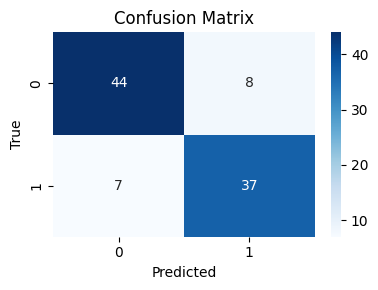


Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.85      0.85        52
         1.0       0.82      0.84      0.83        44

    accuracy                           0.84        96
   macro avg       0.84      0.84      0.84        96
weighted avg       0.84      0.84      0.84        96



In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define hyperparameter space
param_dist = {
    'n_estimators': [100],
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'],
    'max_leaf_nodes': randint(3, 10),
    'ccp_alpha': [0.0, 0.005, 0.01, 0.02, 0.04, 0.08],
    'class_weight': ['balanced']
}

# Set up randomized search
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=1),
    param_distributions=param_dist,
    n_iter=30,           
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=1
)

# Run it
rf_random.fit(X_cv, y_cv)

# Results
print("Best Params:", rf_random.best_params_)
print("best accuracy:", rf_random.best_score_)

best_model = rf_random.best_estimator_
y_pred = best_model.predict(X_cv)


cm = confusion_matrix(y_cv, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print("\nClassification Report:\n", classification_report(y_cv, y_pred))



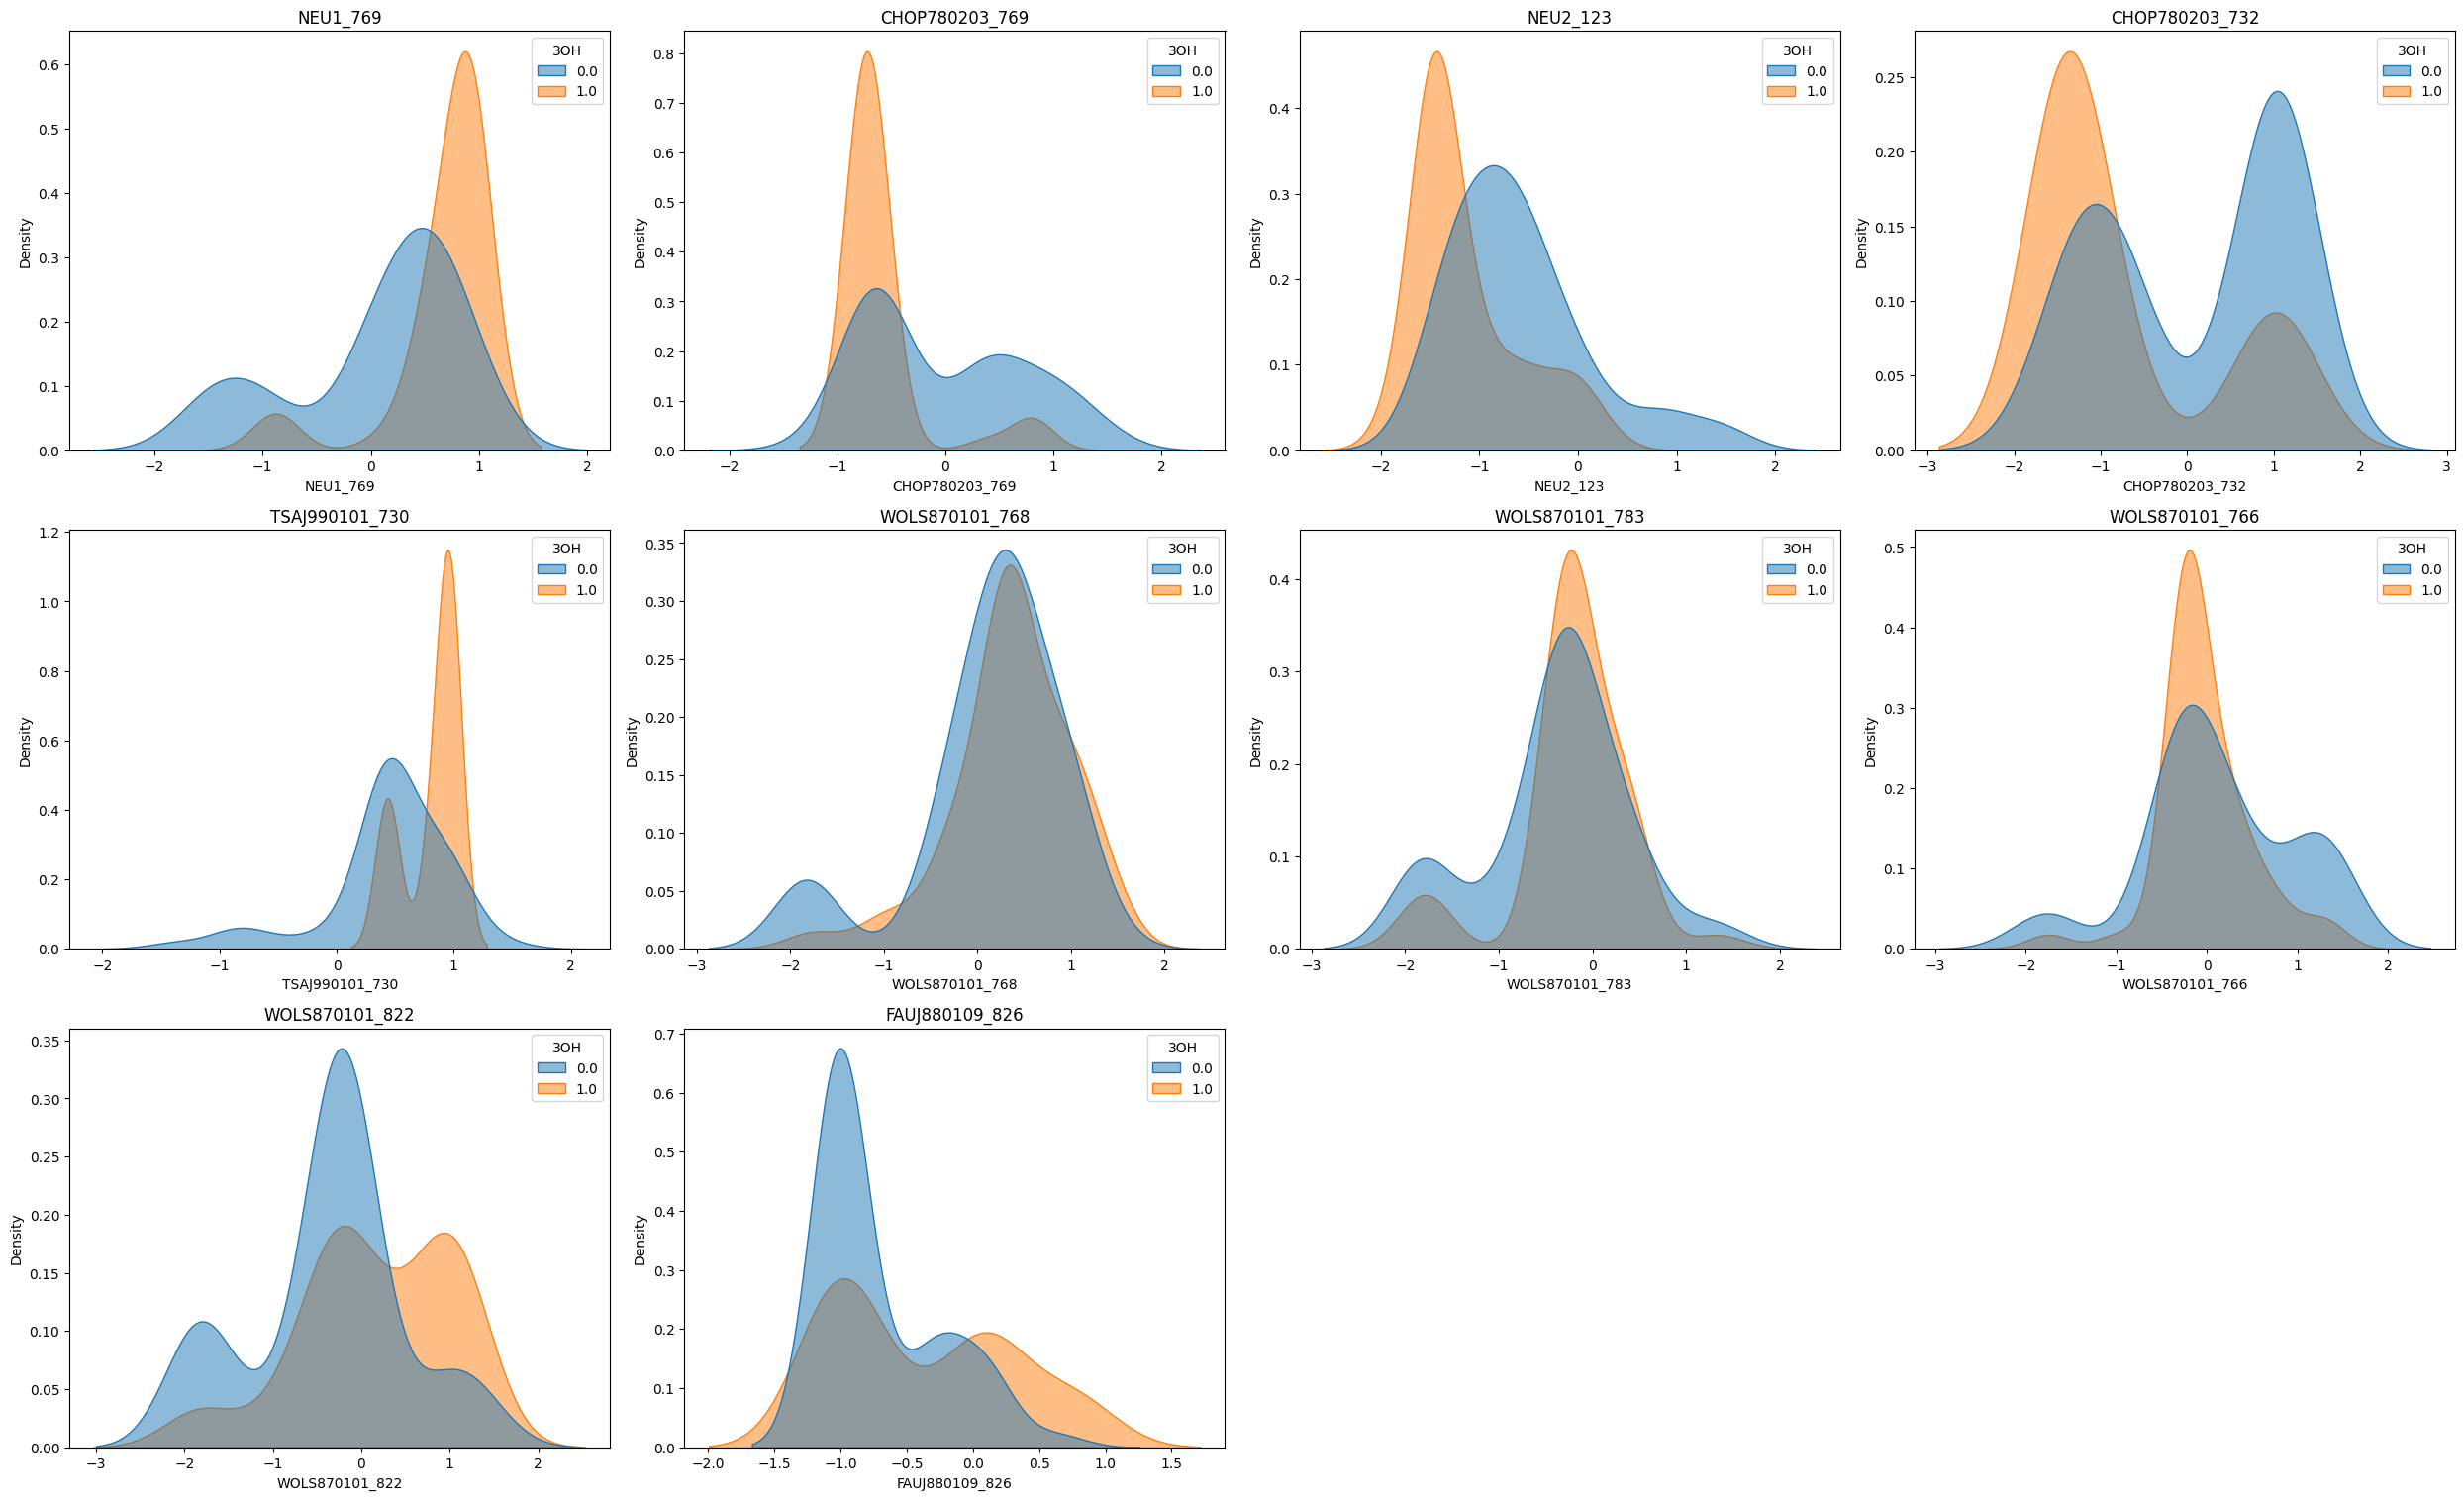

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop unnecessary columns
df = ml_df_train.drop(['cond_accession', 'aligned_seq'], axis=1)

# Get top N important features
top_features = importances.sort_values(ascending=False).head(32).index

# Plot KDEs
plt.figure(figsize=(25, 40))

for i, column in enumerate(top_features):
    plt.subplot(8, 4, i+1)
    sns.kdeplot(data=df, x=column, hue="3OH", fill=True, alpha=0.5)
    plt.title(column)

plt.tight_layout()
plt.show()


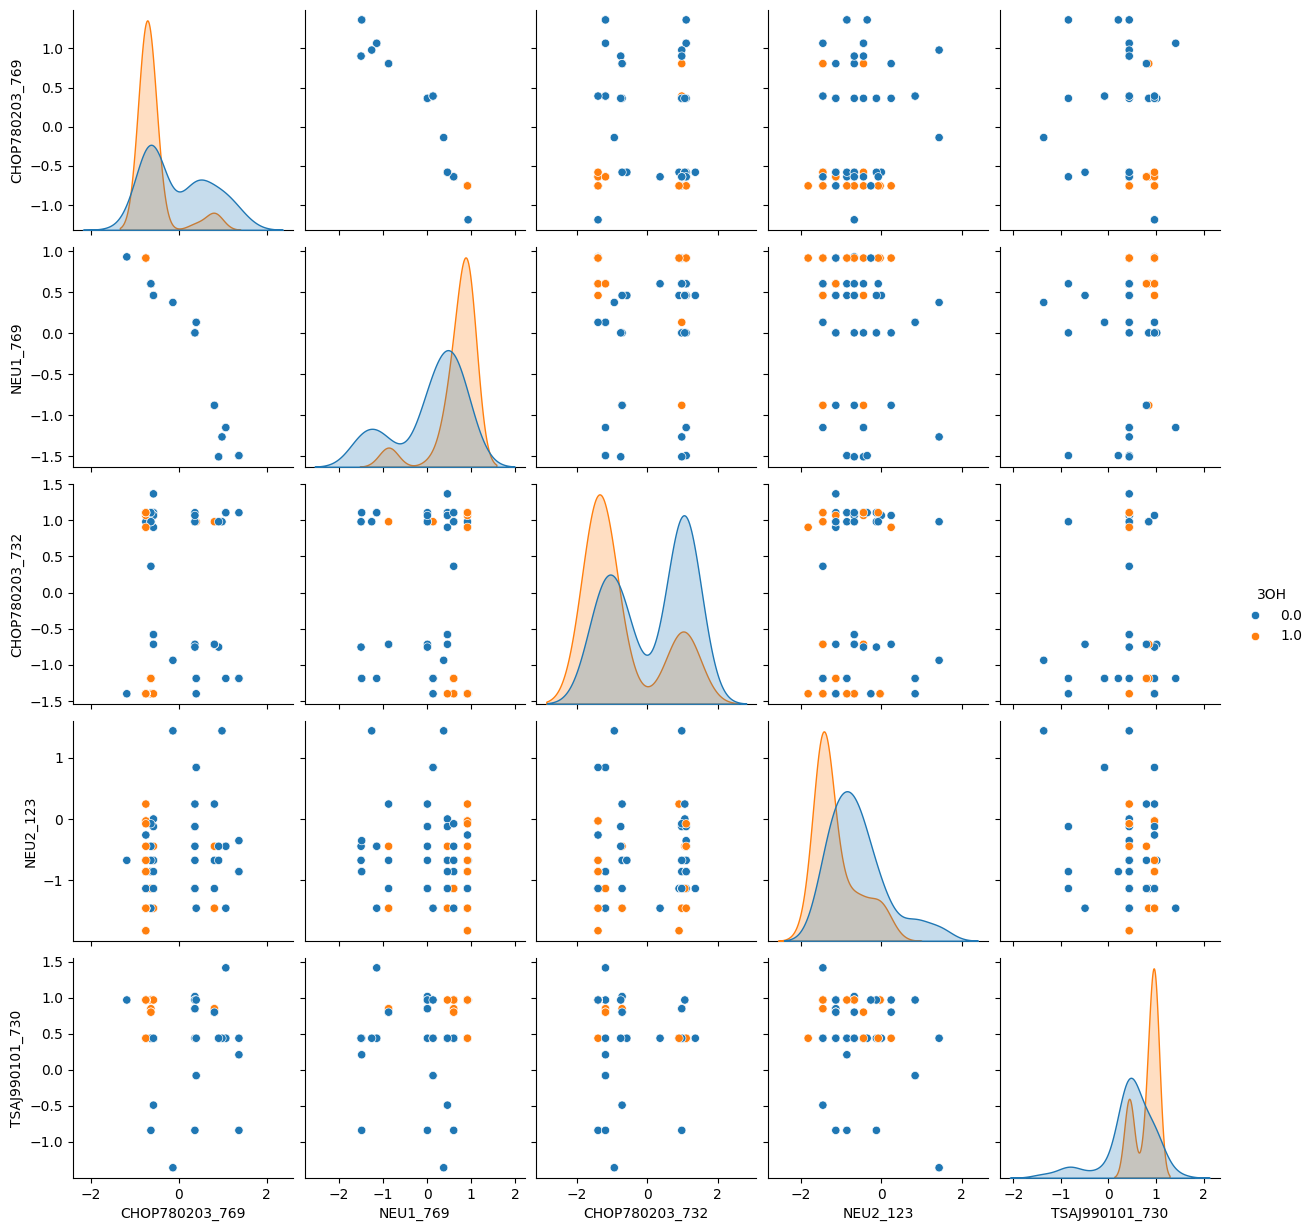

In [18]:
sns.pairplot(ml_df_train[["CHOP780203_769", "NEU1_769", "CHOP780203_732", "NEU2_123","TSAJ990101_730", "3OH"]], hue="3OH")

# gradient boost

[0.8        0.63157895 0.73684211 0.78947368 0.78947368] avg: 0.7494736842105263
Confusion Matrix:
 [[40 12]
 [12 32]]


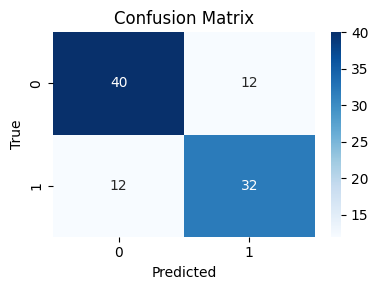


training accuracy : [0.86842105 0.87012987 0.87012987 0.87012987 0.87012987] avg: 0.8697881066302118
test accuracy : [0.8        0.63157895 0.73684211 0.78947368 0.78947368] avg: 0.7494736842105263


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate
from sklearn.metrics import confusion_matrix

# Define model
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=25,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    subsample=1.0,  # Try stochastic boosting
    random_state=i
)

# Cross-validation
cvs = cross_val_score(gb_model, X_cv, y_cv, cv=5)
print(cvs, 'avg:', avg(cvs))

# Predictions
cvs_pred = cross_val_predict(gb_model, X_cv, y_cv, cv=5)
cvoutput = cross_validate(gb_model, X_cv, y_cv, cv=5, return_train_score=True)

cm = confusion_matrix(y_cv, cvs_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print('\ntraining accuracy :', cvoutput['train_score'], 'avg:', avg(cvoutput['train_score']))
print('test accuracy :', cvoutput['test_score'], 'avg:', avg(cvoutput['test_score']))



Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50, 'subsample': 1.0}
Best score: 0.8226315789473684
Confusion Matrix:
 [[52  0]
 [ 0 44]]


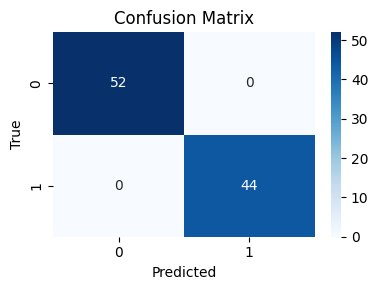


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        52
         1.0       1.00      1.00      1.00        44

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



In [20]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV


param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [25, 50, 100],         # keep it small
    'max_depth': [2, 3, 4],                # shallow trees
    'min_samples_split': [2, 3, 5],        # allow splits but not too greedy
    'min_samples_leaf': [1, 2, 4],         # small leaf sizes
    'max_features': ['sqrt', 'log2'],      # feature subsampling
    'subsample': [1.0]                     # use full data since it's small
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_cv, y_cv)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_cv)


cm = confusion_matrix(y_cv, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print("\nClassification Report:\n", classification_report(y_cv, y_pred))


# svm

Confusion Matrix:
 [[40 12]
 [11 33]]


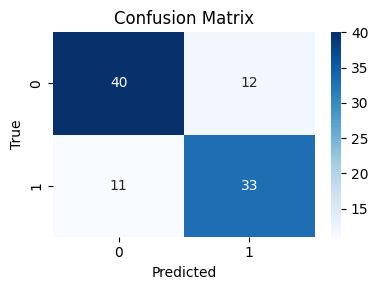


training accuracy :  [0.84210526 0.76623377 0.81818182 0.83116883 0.77922078] avg: 0.8073820915926179
test accuracy :  [0.75       0.78947368 0.73684211 0.73684211 0.78947368] avg: 0.7605263157894736
                       cond_accession  3OH  predicted_label
124                  COND0001715-octA  1.0              0.0
155                  COND0002050-necA  1.0              0.0
82                   COND0001152-fusA  1.0              0.0
144                  COND0001967-adeG  0.0              1.0
62              COND0000464-XDD1_2281  0.0              1.0
176         COND0002336-H9D14_RS10900  0.0              1.0
131            COND0001806-APU91750.1  0.0              1.0
56                   COND0000449-triD  1.0              0.0
215  COND0002660-SAMN04488128_1011792  0.0              1.0
125             COND0001716-XNC2_2373  0.0              1.0
70             COND0001036-AGZ15476.1  1.0              0.0
203                  COND0002521-psoA  0.0              1.0
40                 

0.09687642275391666

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns


y = ml_df_train['3OH']
X = ml_df_train.drop(['cond_accession', '3OH', 'aligned_seq'], axis=1)

y_test = ml_df_test['3OH']
X_test = ml_df_test.drop(['cond_accession', '3OH', 'aligned_seq'], axis=1)

i=1
X, y = shuffle(X, y, random_state=i)

#X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size=0.2,stratify=ml_df["category"],shuffle=True, random_state=i)

rf_model_cv = svm.SVC(class_weight='balanced', C=1.14, degree=2, gamma='auto', kernel='linear')
#rf_model_cv = svm.SVC(probability=True, class_weight='balanced')
cvs = cross_val_score(rf_model_cv, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)

# print(y, cvs_pred)
cm = confusion_matrix(y, cvs_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = X[y != cvs_pred]
misclassified_ids = ml_df_train.loc[misclassified.index]


misclassified_ids['predicted_label'] = cvs_pred[y != cvs_pred]
#print(misclassified)
print(misclassified_ids[['cond_accession', '3OH', 'predicted_label']])

rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
print(confusion_matrix(y_test, pred))
print('test set :')
print(accuracy_score(y_test, pred))

import statistics
statistics.stdev([0.85526316,0.81818182,0.84415584,0.76623377,0.83116883])
statistics.stdev([0.7,0.84210526,0.73684211,0.94736842,0.78947368])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'C': 69.39175614145937, 'class_weight': 'balanced', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.8125
Confusion Matrix:
 [[52  0]
 [ 0 44]]


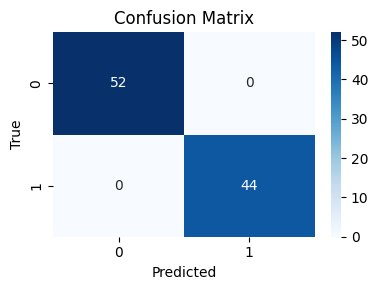


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        52
         1.0       1.00      1.00      1.00        44

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Define hyperparameter space
param_dist = {
    'C': loguniform(1e-3, 1e2),            # regularization strength
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],           # for non-linear kernels
    'degree': [2, 3, 4],                  # only used if kernel='poly'
    'class_weight': ['balanced']
}

svc = SVC(probability=True, random_state=1)

search = RandomizedSearchCV(
    svc,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=1
)

search.fit(X_cv, y_cv)

print("Best Params:", search.best_params_)
print("Best Score:", search.best_score_)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

best_model = search.best_estimator_
y_pred = best_model.predict(X_cv)


cm = confusion_matrix(y_cv, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print("\nClassification Report:\n", classification_report(y_cv, y_pred))



# logistic regression

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'C': 4.680965260176398, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.7916666666666666
Confusion Matrix:
 [[42 10]
 [ 9 35]]


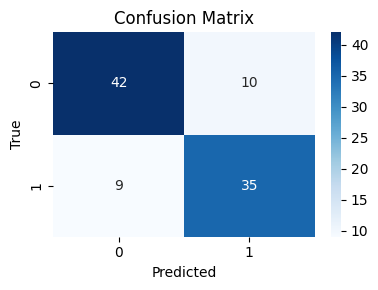


Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.81      0.82        52
         1.0       0.78      0.80      0.79        44

    accuracy                           0.80        96
   macro avg       0.80      0.80      0.80        96
weighted avg       0.80      0.80      0.80        96

test set confusion matrix: 
[[12  1]
 [ 2  9]]
test set :
0.875


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Use loguniform so C spans multiple orders of magnitude
param_dist = {
    'C': loguniform(1e-4, 1e2),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # 'saga' for elasticnet
    'class_weight': ['balanced']
}

logreg = LogisticRegression(max_iter=1000, random_state=1)

search = RandomizedSearchCV(
    logreg,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=1
)

search.fit(X_cv, y_cv)

print("Best Params:", search.best_params_)
print("Best Score:", search.best_score_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_cv)


cm = confusion_matrix(y_cv, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print("\nClassification Report:\n", classification_report(y_cv, y_pred))

rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
print(confusion_matrix(y_test, pred))
print('test set :')
print(accuracy_score(y_test, pred))

[0.65       0.73684211 0.73684211 0.63157895 0.84210526] 0.7194736842105263
Confusion Matrix:
 [[34 10]
 [17 35]]


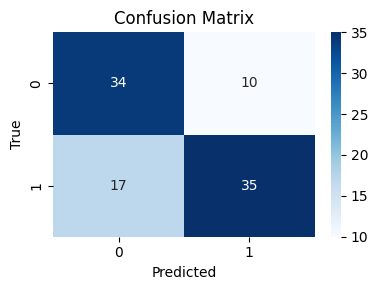


training accuracy :  [0.80263158 0.75324675 0.81818182 0.81818182 0.79220779] avg: 0.7968899521531101
test accuracy :  [0.65       0.73684211 0.73684211 0.63157895 0.84210526] avg: 0.7194736842105263
     3OH                    cond_accession
19   1.0                  COND0000362-pstA
116  0.0            COND0001608-AAW51_2719
110  1.0            COND0001519-STRAU_0349
63   0.0             COND0000464-XDD1_2286
176  0.0         COND0002336-H9D14_RS10900
122  0.0           COND0001686-BN712_00198
8    0.0               COND0000315-SCO3230
130  0.0           COND0001796-BrL25_22185
175  0.0                  COND0002327-bolH
117  1.0         COND0001614-PL8927_110045
214  1.0            COND0002654-UHJ79953.1
56   1.0                  COND0000449-triD
144  0.0                  COND0001967-adeG
124  1.0                  COND0001715-octA
70   1.0            COND0001036-AGZ15476.1
149  0.0                  COND0001984-speA
111  0.0            COND0001524-Sulba_0748
203  0.0                 

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_70926/3360709664.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df_train[y != cvs_pred]


In [24]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df_train['3OH']
X = ml_df_train.drop(['cond_accession','3OH', 'aligned_seq'], axis=1)
X, y = shuffle(X, y, random_state=i)

# lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.003)
lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=1.0435)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
cm = confusion_matrix(y, cvs_pred, labels=[1, 0])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df_train[y != cvs_pred]
print(misclassified.iloc[:,:2])

In [31]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 0

y = ml_df_full['3OH']
X = ml_df_full.drop(['cond_accession','3OH', 'aligned_seq'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['3OH']
X_test = ml_df_test.drop(['cond_accession', '3OH', 'aligned_seq'], axis=1)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.003)

# cvs = cross_val_score(lreg, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
# cvs_pred = cross_val_predict(lreg, X, y, cv=5)
# cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
# print(confusion_matrix(y, cvs_pred, labels=[1, 0]))
# print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
# print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

#misclassified = ml_df[y != cvs_pred]
#print(misclassified.iloc[:,:2])

lreg.fit(X,y)

pred = lreg.predict(X_test)
print('test set confusion matrix: ')
confusion_matrix(y_test, pred, labels=[1, 0])
print('test set :')
print(accuracy_score(y_test, pred))

test set confusion matrix: 
test set :
0.875


In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df_full['category']
X = ml_df_full.drop(['id','category', 'aligned_seq'], axis=1)
X, y = shuffle(X, y, random_state=i)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.003)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
print(confusion_matrix(y, cvs_pred, labels=[1, 0]))
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print(misclassified.iloc[:,:2])

[0.82608696 0.65217391 0.77272727 0.81818182 0.72727273] 0.7592885375494072
[[35 12]
 [15 50]]

training accuracy :  [0.83146067 0.82022472 0.85555556 0.85555556 0.85555556] avg: 0.8436704119850187
test accuracy :  [0.82608696 0.65217391 0.77272727 0.81818182 0.72727273] avg: 0.7592885375494072
                          id  category
2     COND0001608-AAW51_2719         0
4   COND0002432-BRLA_c025650         0
9    COND0001095-RBAM_018460         1
12   COND0002359-FM076_21195         1
17     COND0000464-XDD1_2286         0
20   COND0001686-BN712_00198         0
23          COND0000362-pstA         1
27    COND0001806-APU91750.1         0
40    COND0001524-Sulba_0748         0
45          COND0002521-psoA         0
49          COND0000449-triD         1
50     COND0000464-XDD1_2281         0
53          COND0001657-lesA         1
59    COND0001536-ATY37608.1         0
63    COND0000461-AEP18656.1         1
64     COND0001133-XBJ1_0775         0
67   COND0002119-J6386_25750         0
68

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_95007/2857410524.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [33]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score, balanced_accuracy_score
from sklearn.utils import shuffle


i = 1

y_test = ml_df_test['3OH']
X_test = ml_df_test.drop(['cond_accession','3OH', 'aligned_seq'], axis=1)

with open('test_accuracies_full_3oh.csv', 'w') as f:
    for i in range(0,200):
        print(i)
        y = ml_df_full['3OH']
        X = ml_df_full.drop(['cond_accession','3OH', 'aligned_seq'], axis=1)
        X, y = shuffle(X, y,random_state=i)

        
        rf_model_cv = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.003)

        cvs = cross_val_score(rf_model_cv, X, y, cv=5)
        print(cvs, 'avg:',  avg(cvs))
        cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
        cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)
        print(confusion_matrix(y, cvs_pred, labels=[1, 0]))
        print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))

        print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))
        for testscore in cvoutput['test_score']:
            f.write(str(testscore) + '\n' )


rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
print(confusion_matrix(y_test, pred, labels=[1, 0]))
print('test set :')
print(accuracy_score(y_test, pred))
print(balanced_accuracy_score(y_test, pred))

0
[0.70833333 0.54166667 0.75       0.70833333 0.75      ] avg: 0.6916666666666667
[[44 11]
 [26 39]]

training accuracy :  [0.73958333 0.77083333 0.73958333 0.73958333 0.66666667] avg: 0.73125
test accuracy :  [0.70833333 0.54166667 0.75       0.70833333 0.75      ] avg: 0.6916666666666667
1
[0.66666667 0.66666667 0.75       0.83333333 0.70833333] avg: 0.725
[[44 11]
 [22 43]]

training accuracy :  [0.76041667 0.75       0.72916667 0.69791667 0.71875   ] avg: 0.73125
test accuracy :  [0.66666667 0.66666667 0.75       0.83333333 0.70833333] avg: 0.725
2
[0.70833333 0.83333333 0.75       0.58333333 0.70833333] avg: 0.7166666666666668
[[45 10]
 [24 41]]

training accuracy :  [0.70833333 0.69791667 0.73958333 0.76041667 0.73958333] avg: 0.7291666666666667
test accuracy :  [0.70833333 0.83333333 0.75       0.58333333 0.70833333] avg: 0.7166666666666668
3
[0.70833333 0.625      0.66666667 0.75       0.75      ] avg: 0.7
[[44 11]
 [25 40]]

training accuracy :  [0.71875    0.76041667 0.72916